# IDRiD — Binary Diabetic Retinopathy Classification (No DR vs DR≥1) — CNN Ensemble
**Created:** 2025-08-21 14:43

This notebook implements a complete workflow for **binary classification** on the **IDRiD** fundus dataset:

- **Task:** No DR (label 0) vs DR≥1 (label 1)
- **Data:** Images in `/kaggle/input/idrid-dataset/Imagenes/Imagenes` and labels in `/kaggle/input/idrid-dataset/idrid_labels.csv`
- **Split:** Stratified **70/15/15** train/valid/test
- **Models:** Ensemble of **EfficientNet-B0**, **ResNet-50**, **DenseNet-121** (from `timm`)
- **Training:** BCEWithLogitsLoss, early stopping, cosine LR schedule
- **Evaluation:** Accuracy, ROC-AUC, PR-AUC, F1, Sensitivity/Specificity, Confusion Matrix
- **Calibration:** Temperature scaling on validation
- **Ensemble:** Soft-voting (average probabilities)
- **Explainability:** Grad-CAM for a few samples

> You can run as-is on Kaggle. Adjust `CFG` as needed (epochs, image size, batch size, etc.).


In [1]:

# If running on Kaggle, these are generally available or installable.
# Safe-guard installs (no-op if already present).
try:
    import timm  # type: ignore
except Exception:
    %pip install -q timm

try:
    import albumentations as A  # type: ignore
except Exception:
    %pip install -q albumentations

try:
    import sklearn  # type: ignore
except Exception:
    %pip install -q scikit-learn

try:
    import matplotlib  # type: ignore
except Exception:
    %pip install -q matplotlib

try:
    import seaborn  # type: ignore
except Exception:
    %pip install -q seaborn

try:
    import pytorch_grad_cam  # type: ignore
except Exception:
    %pip install -q grad-cam


In [2]:

import os, random, time, math, gc, json
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, roc_auc_score, average_precision_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)

import matplotlib.pyplot as plt
import seaborn as sns

# Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class CFG:
    seed = 42
    img_dir = "/kaggle/input/idrid-dataset/Imagenes/Imagenes"
    csv_path = "/kaggle/input/idrid-dataset/idrid_labels.csv"
    out_dir = "./idrid_outputs"

    # Data
    img_size = 512   # 448–640 good trade-off; adjust for VRAM
    norm_mean = (0.485, 0.456, 0.406)
    norm_std  = (0.229, 0.224, 0.225)

    # Split
    train_ratio = 0.70
    valid_ratio = 0.15  # test will be 1 - train - valid

    # Training
    epochs = 10
    batch_size = 8
    lr = 2e-4
    weight_decay = 1e-5
    num_workers = 2

    # Models to ensemble
    backbones = [
        "efficientnet_b0",
        "resnet50",
        "densenet121",
    ]

    # Early stopping
    es_patience = 3

    # Calibration
    do_calibration = True

    # Grad-CAM
    do_gradcam = True
    gradcam_samples = 4

os.makedirs(CFG.out_dir, exist_ok=True)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(CFG.seed)
print("Device:", DEVICE)


Device: cuda


In [3]:

df = pd.read_csv(CFG.csv_path)
# Normalize column names, strip spaces
df.columns = [c.strip() for c in df.columns]

# We expect 'id_code' and 'diagnosis' present
assert "id_code" in df.columns, df.columns
assert "diagnosis" in df.columns, df.columns

# Map to binary: 0 if diagnosis == 0 else 1
# Some IDRiD releases use 0..4 grading. Adjust accordingly.
df["label"] = (df["diagnosis"].astype(int) > 0).astype(int)

# Build full image path
def build_path(id_code):
    # Images are typically named like 'IDRiD_001.jpg'
    return os.path.join(CFG.img_dir, f"{id_code}.jpg")

df["image_path"] = df["id_code"].apply(build_path)
# Filter rows with missing files just in case
df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)
print(df.head())
print("Counts:", df["label"].value_counts().to_dict())


     id_code  diagnosis  Risk of macular edema  Unnamed: 3  Unnamed: 4  \
0  IDRiD_001          3                      2         NaN         NaN   
1  IDRiD_002          3                      2         NaN         NaN   
2  IDRiD_003          2                      2         NaN         NaN   
3  IDRiD_004          3                      2         NaN         NaN   
4  IDRiD_005          4                      0         NaN         NaN   

   Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  \
0         NaN         NaN         NaN         NaN         NaN          NaN   
1         NaN         NaN         NaN         NaN         NaN          NaN   
2         NaN         NaN         NaN         NaN         NaN          NaN   
3         NaN         NaN         NaN         NaN         NaN          NaN   
4         NaN         NaN         NaN         NaN         NaN          NaN   

  Unnamed: 11  label                                         image_path  
0         Na

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


In [4]:

# First split train vs temp (valid+test), then split temp into valid and test
train_df, temp_df = train_test_split(
    df, test_size=(1.0 - CFG.train_ratio),
    stratify=df["label"], random_state=CFG.seed
)

# Compute valid proportion within temp
valid_prop_of_temp = CFG.valid_ratio / (1.0 - CFG.train_ratio)
valid_df, test_df = train_test_split(
    temp_df, test_size=(1.0 - valid_prop_of_temp),
    stratify=temp_df["label"], random_state=CFG.seed
)

for name, d in [("train", train_df), ("valid", valid_df), ("test", test_df)]:
    print(name, d.shape, d["label"].value_counts(normalize=True).to_dict())

train_df.to_csv(os.path.join(CFG.out_dir, "train_split.csv"), index=False)
valid_df.to_csv(os.path.join(CFG.out_dir, "valid_split.csv"), index=False)
test_df.to_csv(os.path.join(CFG.out_dir, "test_split.csv"), index=False)


train (318, 14) {1: 0.7169811320754716, 0: 0.2830188679245283}
valid (68, 14) {1: 0.7205882352941176, 0: 0.27941176470588236}
test (69, 14) {1: 0.7101449275362319, 0: 0.2898550724637681}


In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

# --- helpers to be robust across v1/v2 variations ---
def RRC(h, w, **kwargs):
    # prefer v2 style
    try:
        return A.RandomResizedCrop(size=(h, w), **kwargs)
    except Exception:
        return A.RandomResizedCrop(height=h, width=w, **kwargs)

def CCrop(h, w, **kwargs):
    # try both signatures
    try:
        return A.CenterCrop(size=(h, w), **kwargs)
    except Exception:
        return A.CenterCrop(height=h, width=w, **kwargs)

def PadMin(h, w, **kwargs):
    # PadIfNeeded: don't pass `value` (some builds warn / reject it).
    # If you need constant fill, use cv2.BORDER_CONSTANT and (optionally) border_value.
    base = dict(min_height=h, min_width=w, border_mode=cv2.BORDER_CONSTANT)
    base.update(kwargs)
    return A.PadIfNeeded(**base)

# --- your transforms ---
train_tfms = A.Compose([
    A.LongestMaxSize(max_size=CFG.img_size),
    PadMin(CFG.img_size, CFG.img_size),  # no `value=` here; uses default 0 for constant padding
    RRC(CFG.img_size, CFG.img_size, scale=(0.85, 1.0), ratio=(0.9, 1.1), p=0.8),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(p=0.6),
    A.CLAHE(clip_limit=2.0, p=0.2),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=CFG.norm_mean, std=CFG.norm_std),
    ToTensorV2(),
])

valid_tfms = A.Compose([
    A.LongestMaxSize(max_size=CFG.img_size),
    PadMin(CFG.img_size, CFG.img_size),
    CCrop(CFG.img_size, CFG.img_size, p=1.0),
    A.Normalize(mean=CFG.norm_mean, std=CFG.norm_std),
    ToTensorV2(),
])


# ---------------------------
# Simple fundus preprocessing: center crop to remove black borders via square crop
def load_fundus_image(path):
    img = Image.open(path).convert("RGB")
    # Square center-crop
    w, h = img.size
    s = min(w, h)
    left = (w - s) // 2
    top = (h - s) // 2
    img = img.crop((left, top, left + s, top + s))
    return img

class IDRiDDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_fundus_image(row.image_path)
        img = np.array(img)
        if self.transforms:
            img = self.transforms(image=img)["image"]
        label = torch.tensor(row.label, dtype=torch.float32)
        return img, label


In [6]:

def build_model(backbone: str, pretrained=True):
    model = timm.create_model(backbone, pretrained=pretrained, num_classes=1)
    return model

class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.count = 0
        self.sum = 0.0
    def update(self, val, n=1):
        self.sum += val * n
        self.count += n
    @property
    def avg(self):
        return self.sum / max(1, self.count)

@torch.no_grad()
def evaluate(model, loader, device=DEVICE):
    model.eval()
    all_logits, all_labels = [], []
    loss_fn = nn.BCEWithLogitsLoss()
    loss_meter = AverageMeter()
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).unsqueeze(1)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss_meter.update(loss.item(), x.size(0))
        all_logits.append(logits.detach().cpu().numpy())
        all_labels.append(y.detach().cpu().numpy())
    logits = np.concatenate(all_logits, axis=0).ravel()
    labels = np.concatenate(all_labels, axis=0).ravel()
    probs = 1 / (1 + np.exp(-logits))
    return loss_meter.avg, logits, probs, labels

def train_one_model(backbone, train_loader, valid_loader, fold_tag="main"):
    model = build_model(backbone, pretrained=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    # Cosine annealing with warmup-like behavior using T_max=epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.epochs)
    loss_fn = nn.BCEWithLogitsLoss()

    best_val = float("inf")
    best_path = os.path.join(CFG.out_dir, f"best_{backbone}_{fold_tag}.pt")
    patience = CFG.es_patience
    bad = 0

    for epoch in range(1, CFG.epochs+1):
        model.train()
        loss_meter = AverageMeter()
        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True).unsqueeze(1)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()
            loss_meter.update(loss.item(), x.size(0))
        scheduler.step()

        val_loss, _, _, _ = evaluate(model, valid_loader, DEVICE)
        print(f"[{backbone}] Epoch {epoch:02d}/{CFG.epochs} | train_loss={loss_meter.avg:.4f} | val_loss={val_loss:.4f}")

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            torch.save(model.state_dict(), best_path)
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping at epoch {epoch}. Best val_loss={best_val:.4f}")
                break

    # Load best
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model, best_path


In [7]:

train_ds = IDRiDDataset(train_df, transforms=train_tfms)
valid_ds = IDRiDDataset(valid_df, transforms=valid_tfms)
test_ds  = IDRiDDataset(test_df,  transforms=valid_tfms)

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=CFG.num_workers, pin_memory=True, drop_last=False)
valid_loader = DataLoader(valid_ds, batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True, drop_last=False)

len(train_ds), len(valid_ds), len(test_ds)


(318, 68, 69)

In [8]:

trained = {}
for bk in CFG.backbones:
    print(f"\n==== Training {bk} ====")
    model, path = train_one_model(bk, train_loader, valid_loader)
    trained[bk] = dict(model=model, path=path)
json.dump({k:v["path"] for k,v in trained.items()},
          open(os.path.join(CFG.out_dir, "model_paths.json"), "w"))
print("Saved:", os.path.join(CFG.out_dir, "model_paths.json"))



==== Training efficientnet_b0 ====
[efficientnet_b0] Epoch 01/10 | train_loss=1.1455 | val_loss=0.3371
[efficientnet_b0] Epoch 02/10 | train_loss=0.6501 | val_loss=0.3362
[efficientnet_b0] Epoch 03/10 | train_loss=0.4300 | val_loss=0.3572
[efficientnet_b0] Epoch 04/10 | train_loss=0.2877 | val_loss=0.3504
[efficientnet_b0] Epoch 05/10 | train_loss=0.3050 | val_loss=0.3404
Early stopping at epoch 5. Best val_loss=0.3362

==== Training resnet50 ====


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

[resnet50] Epoch 01/10 | train_loss=0.5954 | val_loss=0.4745
[resnet50] Epoch 02/10 | train_loss=0.4609 | val_loss=0.3876
[resnet50] Epoch 03/10 | train_loss=0.4017 | val_loss=0.3198
[resnet50] Epoch 04/10 | train_loss=0.3605 | val_loss=0.3157
[resnet50] Epoch 05/10 | train_loss=0.3483 | val_loss=0.2769
[resnet50] Epoch 06/10 | train_loss=0.3191 | val_loss=0.2737
[resnet50] Epoch 07/10 | train_loss=0.3142 | val_loss=0.2613
[resnet50] Epoch 08/10 | train_loss=0.3137 | val_loss=0.2580
[resnet50] Epoch 09/10 | train_loss=0.2846 | val_loss=0.2460
[resnet50] Epoch 10/10 | train_loss=0.2836 | val_loss=0.2486

==== Training densenet121 ====


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

[densenet121] Epoch 01/10 | train_loss=0.4459 | val_loss=0.2776
[densenet121] Epoch 02/10 | train_loss=0.3003 | val_loss=0.1635
[densenet121] Epoch 03/10 | train_loss=0.2542 | val_loss=0.1942
[densenet121] Epoch 04/10 | train_loss=0.2088 | val_loss=0.2029
[densenet121] Epoch 05/10 | train_loss=0.1791 | val_loss=0.1319
[densenet121] Epoch 06/10 | train_loss=0.1957 | val_loss=0.1410
[densenet121] Epoch 07/10 | train_loss=0.1320 | val_loss=0.1225
[densenet121] Epoch 08/10 | train_loss=0.1204 | val_loss=0.1260
[densenet121] Epoch 09/10 | train_loss=0.1183 | val_loss=0.1230
[densenet121] Epoch 10/10 | train_loss=0.1289 | val_loss=0.1531
Early stopping at epoch 10. Best val_loss=0.1225
Saved: ./idrid_outputs/model_paths.json


In [15]:

class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)
    def forward(self, x):
        logits = self.model(x)
        return logits / self.temperature.clamp_min(1e-3)

@torch.no_grad()
def find_temperature(model, valid_loader):
    model.eval()
    logits_all = []
    labels_all = []
    for x, y in valid_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE).unsqueeze(1)
        logits = model(x)
        logits_all.append(logits.detach().cpu().numpy())
        labels_all.append(y.detach().cpu().numpy())
    logits = np.concatenate(logits_all).ravel()
    labels = np.concatenate(labels_all).ravel()

    # Optimize temperature by minimizing NLL (here use simple grid search)
    temps = np.linspace(0.5, 3.0, 26)
    best_t, best_nll = 1.0, float("inf")
    for t in temps:
        z = logits / t
        p = 1 / (1 + np.exp(-z))
        # NLL for binary classification
        eps = 1e-8
        nll = -np.mean(labels*np.log(p+eps) + (1-labels)*np.log(1-p+eps))
        if nll < best_nll:
            best_nll, best_t = nll, t
    return best_t, best_nll


In [16]:

# Evaluate each model
per_model = {}
for bk, obj in trained.items():
    m = obj["model"]
    val_loss, val_logits, val_probs, val_labels = evaluate(m, valid_loader)
    te_loss, te_logits, te_probs, te_labels = evaluate(m, test_loader)
    per_model[bk] = dict(val_loss=val_loss, te_loss=te_loss,
                         val_logits=val_logits, val_probs=val_probs, val_labels=val_labels,
                         te_logits=te_logits, te_probs=te_probs, te_labels=te_labels)
    print(f"[{bk}] valid_loss={val_loss:.4f} test_loss={te_loss:.4f}")

# Optional calibration
temperatures = {}
if CFG.do_calibration:
    for bk, obj in trained.items():
        t, nll = find_temperature(obj["model"], valid_loader)
        temperatures[bk] = t
        print(f"[{bk}] best temperature={t:.3f} (val NLL={nll:.4f})")
else:
    for bk in trained.keys():
        temperatures[bk] = 1.0

# Apply calibration and collect test probabilities
calibrated_test_probs = []
for bk, obj in trained.items():
    t = temperatures[bk]
    te_logits = per_model[bk]["te_logits"] / max(1e-3, t)
    te_probs = 1 / (1 + np.exp(-te_logits))
    calibrated_test_probs.append(te_probs)

# Soft-voting ensemble (average probabilities)
ens_probs = np.mean(np.vstack(calibrated_test_probs), axis=0)
ens_labels = (ens_probs >= 0.5).astype(int)
y_true = per_model[CFG.backbones[0]]["te_labels"]  # same test labels for all


[efficientnet_b0] valid_loss=0.3362 test_loss=0.4078
[resnet50] valid_loss=0.2460 test_loss=0.2570
[densenet121] valid_loss=0.1225 test_loss=0.1432
[efficientnet_b0] best temperature=2.500 (val NLL=0.2330)
[resnet50] best temperature=0.500 (val NLL=0.1836)
[densenet121] best temperature=0.700 (val NLL=0.1109)


In [17]:
# --- JSON helper to convert NumPy → native Python ---
import numpy as np

def to_py(o):
    if isinstance(o, np.generic):
        return o.item()
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (list, tuple)):
        return [to_py(i) for i in o]
    if isinstance(o, dict):
        return {k: to_py(v) for k, v in o.items()}
    return o


efficientnet_b0 Acc=0.8841 AUC=0.9510 AP=0.9826 F1=0.9200 Sens=0.9388 Spec=0.7500
resnet50 Acc=0.9130 AUC=0.9837 AP=0.9936 F1=0.9400 Sens=0.9592 Spec=0.8000
densenet121 Acc=0.9420 AUC=0.9857 AP=0.9948 F1=0.9592 Sens=0.9592 Spec=0.9000
Ensemble Acc=0.9420 AUC=0.9847 AP=0.9944 F1=0.9592 Sens=0.9592 Spec=0.9000


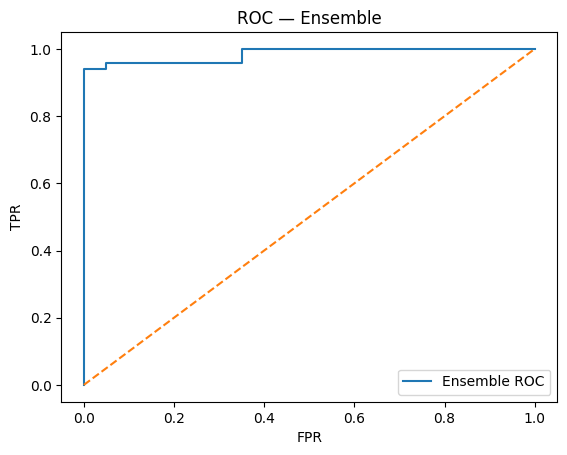

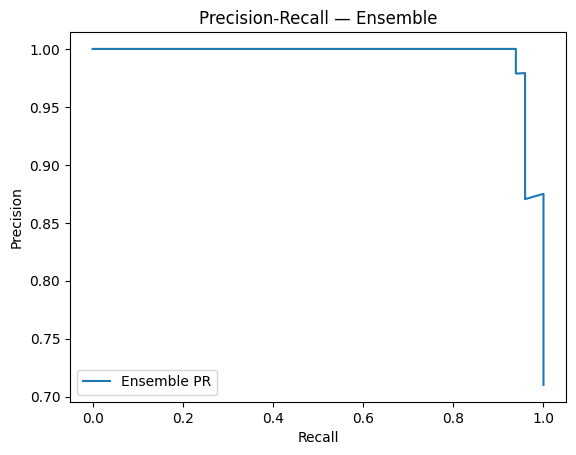

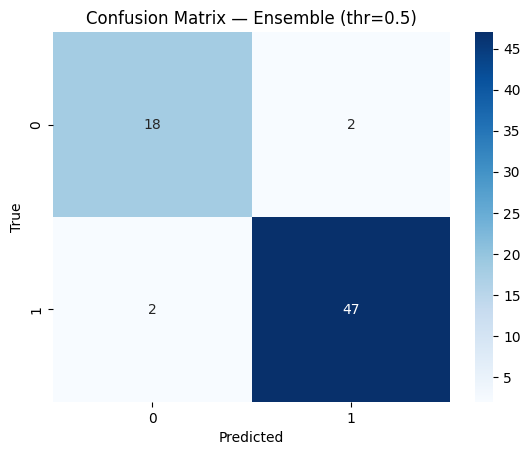

Saved metrics to ./idrid_outputs/results.json


In [18]:

def summarize_metrics(y_true, probs, thr=0.5, title=""):
    preds = (probs >= thr).astype(int)
    acc = accuracy_score(y_true, preds)
    auc = roc_auc_score(y_true, probs)
    ap  = average_precision_score(y_true, probs)
    f1  = f1_score(y_true, preds)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    sens = tp / (tp + fn + 1e-8)  # recall for positive
    spec = tn / (tn + fp + 1e-8)
    print(f"{title} Acc={acc:.4f} AUC={auc:.4f} AP={ap:.4f} F1={f1:.4f} Sens={sens:.4f} Spec={spec:.4f}")
    return dict(acc=acc, auc=auc, ap=ap, f1=f1, sens=sens, spec=spec, cm=(tn, fp, fn, tp))

# Per-model metrics
results = {}
for bk in trained.keys():
    r = summarize_metrics(y_true, per_model[bk]["te_probs"], title=f"{bk}")
    results[bk] = r

# Ensemble metrics
r_ens = summarize_metrics(y_true, ens_probs, title="Ensemble")
results["ensemble"] = r_ens

# ROC curve
fpr, tpr, _ = roc_curve(y_true, ens_probs)
plt.figure()
plt.plot(fpr, tpr, label="Ensemble ROC")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC — Ensemble")
plt.legend()
plt.show()

# PR curve
prec, rec, _ = precision_recall_curve(y_true, ens_probs)
plt.figure()
plt.plot(rec, prec, label="Ensemble PR")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall — Ensemble")
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_true, (ens_probs>=0.5).astype(int))
plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Ensemble (thr=0.5)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# Save results json
# with open(os.path.join(CFG.out_dir, "results.json"), "w") as f:
#     json.dump(results, f, indent=2)
# print("Saved metrics to", os.path.join(CFG.out_dir, "results.json"))
clean = to_py(results)
with open(os.path.join(CFG.out_dir, "results.json"), "w") as f:
    json.dump(clean, f, indent=2)
print("Saved metrics to", os.path.join(CFG.out_dir, "results.json"))

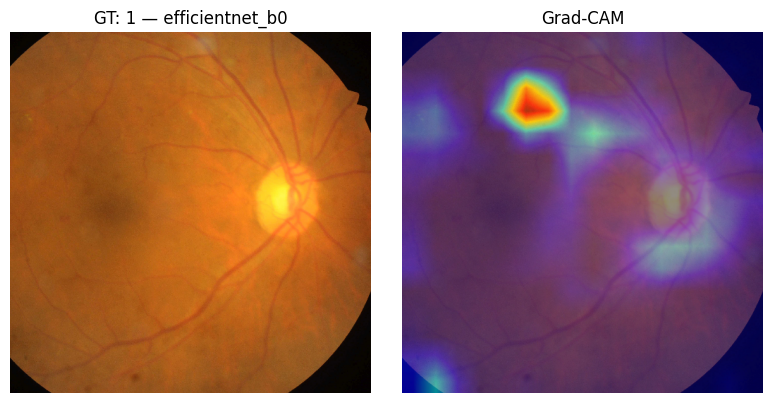

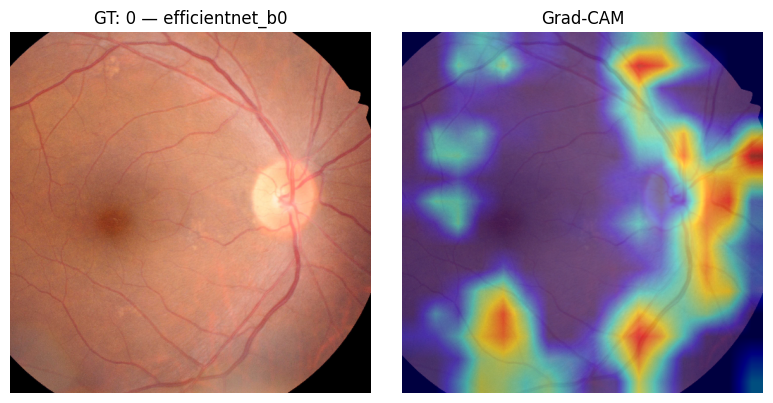

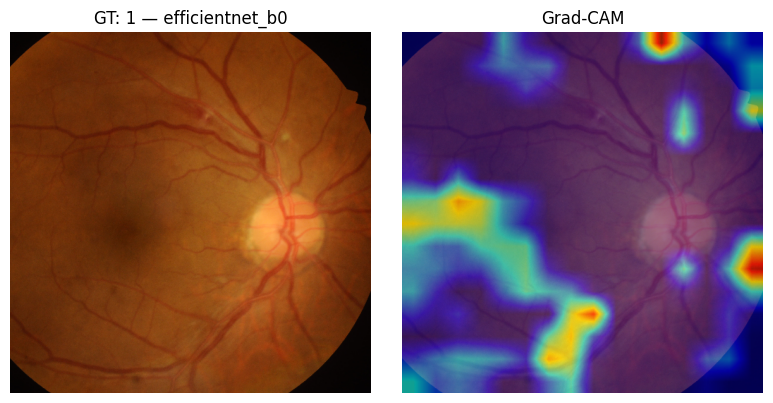

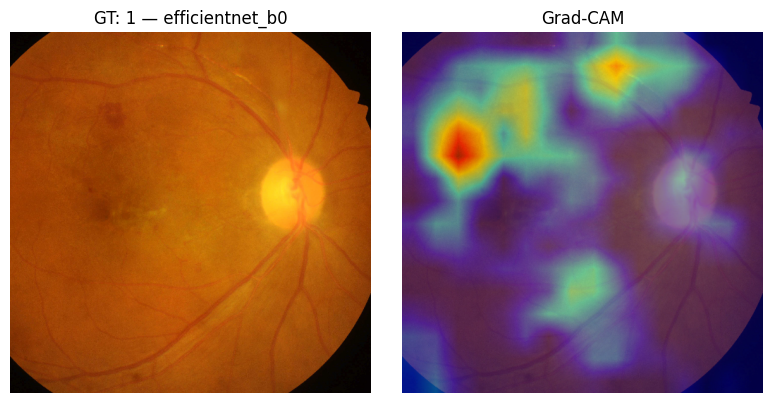

In [25]:
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

if CFG.do_gradcam:
    bk0 = CFG.backbones[0]
    model0 = trained[bk0]["model"].eval()

    # ----- choose a conv layer safely -----
    def pick_target_layer(model, backbone_name):
        if "efficientnet" in backbone_name:
            if hasattr(model, "conv_head") and isinstance(model.conv_head, torch.nn.Conv2d):
                return model.conv_head
            if hasattr(model, "blocks") and len(model.blocks) > 0:
                for m in reversed(list(model.blocks.modules())):
                    if isinstance(m, torch.nn.Conv2d):
                        return m
        if "resnet" in backbone_name and hasattr(model, "layer4"):
            for m in reversed(list(model.layer4[-1].modules())):
                if isinstance(m, torch.nn.Conv2d):
                    return m
        if "densenet" in backbone_name and hasattr(model, "features"):
            for m in reversed(list(model.features.modules())):
                if isinstance(m, torch.nn.Conv2d):
                    return m
        for m in reversed(list(model.modules())):
            if isinstance(m, torch.nn.Conv2d):
                return m
        raise RuntimeError("No suitable conv layer found for Grad-CAM.")
    target_layer = pick_target_layer(model0, bk0)

    # Determine output dimension to set the right target index
    with torch.no_grad():
        dummy = torch.zeros(1, 3, CFG.img_size, CFG.img_size, device=DEVICE)
        out = model0(dummy)
    out_dim = out.shape[-1] if out.ndim > 1 else 1  # should be 1 for our setup

    import random
    indices = random.sample(range(len(test_df)), k=min(CFG.gradcam_samples, len(test_df)))

    for i in indices:
        row = test_df.iloc[i]
        img_pil = load_fundus_image(row.image_path)
        img_np = np.array(img_pil)

        tfm = valid_tfms(image=img_np)
        x = tfm["image"].unsqueeze(0).to(DEVICE)
        rgb = (img_np / 255.0).astype(np.float32)

        try:
            with GradCAM(model=model0, target_layers=[target_layer]) as cam:
                # If single-logit (binary), target index MUST be 0.
                targets = None if out_dim == 1 else [ClassifierOutputTarget(1)]
                if targets is None:
                    grayscale_cam = cam(input_tensor=x, eigen_smooth=False)[0]
                else:
                    grayscale_cam = cam(input_tensor=x, targets=targets, eigen_smooth=False)[0]
        except Exception as e:
            print(f"[Grad-CAM] Skipping {row.id_code}: {e}")
            continue

        H, W = grayscale_cam.shape
        rgb_resized = cv2.resize(rgb, (W, H), interpolation=cv2.INTER_LINEAR)
        cam_vis = show_cam_on_image(rgb_resized, grayscale_cam, use_rgb=True)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(rgb_resized)
        plt.axis("off")
        plt.title(f"GT: {row.label} — {bk0}")

        plt.subplot(1, 2, 2)
        plt.imshow(cam_vis)
        plt.axis("off")
        plt.title("Grad-CAM")
        plt.tight_layout()
        plt.show()



## Notes & Tips

- Adjust `CFG.img_size`, `batch_size`, and `epochs` for your GPU. Larger image sizes often help DR lesion visibility.
- For **class imbalance**, consider focal loss or class weights. (BCEWithLogitsLoss `pos_weight` can be used.)
- To increase ensemble diversity:
  - Train each model on **different seeds**, **augmentations**, or slightly different image sizes.
  - Use **snapshot ensembling** or **test-time augmentation** (TTA) at inference and average predictions.
- For deployment, consider **knowledge distillation** to compress the ensemble to a single student model.
- Use **calibration** to improve probability reliability for clinical decision thresholds.
